# `pycopykat` vs R `copykat` — parity comparison on `exp.rawdata`

This notebook runs **`pycopykat`** (the Python port) and the upstream R **`copykat`** on copykat's bundled 302-cell fixture, then uses **omicverse** for visualisation.

Both implementations process the same gene × cell counts matrix. We compare:
* overlap of the aneuploid sets (Venn),
* aneuploid / diploid classification agreement (confusion matrix +
  ARI / FMI),
* per-cluster aneuploid fraction on a Leiden partition,
* bin-level CNA agreement (Pearson + Spearman + side-by-side
  heatmap + Δ heatmap).

Sister notebook: `compare_py_vs_R_realdata.ipynb` runs the same
comparison on a real-tumour sample using cached outputs.


In [1]:
from __future__ import annotations
import os, subprocess, warnings
from pathlib import Path

warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyreadr
import omicverse as ov
import anndata as ad

import pycopykat
from pycopykat import CopykatConfig, copykat
from pycopykat.viz import (
    plot_cna_heatmap_compare,
    plot_cna_delta,
)

ov.plot_set()
FIXTURE = '/media/jason/T7/rerbulid/copykat-R/data/exp.rawdata.rda'
R_DRIVER = '/media/jason/T7/rerbulid/pycopykat/examples/r_driver_compare.R'
RSCRIPT = os.environ.get('RSCRIPT', 'Rscript')
WORK = Path('./_compare_out_exp_rawdata').resolve()
WORK.mkdir(exist_ok=True)
print('omicverse', ov.__version__, '— pycopykat', pycopykat.__version__)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA GeForce RTX 3070 Laptop GPU
      Memory: 7.8 GB | Compute: 8.6

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 1.7.8   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

omicverse 1.7.8 — pycopykat 0.1.0.dev1


## 1. Load `exp.rawdata` and dump shared counts.tsv

Both implementations consume the same on-disk TSV so there is no
input-format ambiguity.

In [2]:
counts = next(iter(pyreadr.read_r(FIXTURE).values()))
print('shape (genes x cells):', counts.shape)

counts_path = WORK / 'counts.tsv'
if not counts_path.exists():
    counts.to_csv(counts_path, sep='\t')
print('counts ->', counts_path, counts_path.stat().st_size // 1024, 'KB')


shape (genes x cells): (33694, 302)


counts -> /media/jason/T7/rerbulid/pycopykat/examples/_compare_out_exp_rawdata/counts.tsv 20293 KB


## 2. Run R `copykat` via subprocess

Driver script: `examples/r_driver_compare.R`. Output filenames are
stable: `prediction.tsv`, `cna.tsv`, `runinfo.txt`.

In [3]:
r_out = WORK / 'r_out'
r_out.mkdir(exist_ok=True)
if not (r_out / 'prediction.tsv').exists():
    proc = subprocess.run(
        [RSCRIPT, R_DRIVER, str(counts_path), str(r_out), 'exp_rawdata', '1'],
        capture_output=True, text=True,
    )
    print(proc.stdout[-600:])
    if proc.returncode != 0:
        print('STDERR:', proc.stderr[-1200:])
        raise RuntimeError('R driver failed')
r_pred = pd.read_csv(r_out / 'prediction.tsv', sep='\t')
r_cna_raw = pd.read_csv(r_out / 'cna.tsv', sep='\t')
print('R prediction rows:', len(r_pred), '— aneuploid:', (r_pred['copykat.pred']=='aneuploid').sum())
print('R CNA shape (bins x meta+cells):', r_cna_raw.shape)


1] "step 3: smoothing data with dlm ..."
[1] "step 4: measuring baselines ..."
number of iterations= 315 
number of iterations= 679 
number of iterations= 214 
number of iterations= 823 
number of iterations= 431 
number of iterations= 823 
[1] "step 5: segmentation..."
[1] "step 6: convert to genomic bins..."
[1] "step 7: adjust baseline ..."
[1] "step 8: final prediction ..."
[1] "step 9: saving results..."
[1] "step 10: ploting heatmap ..."
Time difference of 2.506911 mins
[R] copykat elapsed: 2.51 min
[R] wrote prediction.tsv (302 rows)
[R] wrote cna.tsv (12167 bins x 302 cells)
[R] done.



R prediction rows: 302 — aneuploid: 229
R CNA shape (bins x meta+cells): (12167, 305)


## 3. Run `pycopykat` inline

In [4]:
result = copykat(counts, config=CopykatConfig(sam_name='exp_rawdata', n_jobs=1))
py_pred = result.prediction.copy()
py_cna = result.cna_mat.copy()
print('py prediction rows:', len(py_pred),
      '— aneuploid:', py_pred['copykat.pred'].astype(str).str.contains('aneuploid').sum())
print('py CNA shape (bins x cells):', py_cna.shape)
print('warnings:', result.warnings)


py prediction rows: 302 — aneuploid: 229
py CNA shape (bins x cells): (12167, 302)
warnings: ()


## 4. Align cell IDs and bin index between the two outputs

R copykat applies `make.names()` to cell IDs (turns hyphens into
dots); pycopykat keeps the original. We map back to the original
form. The two CNA matrices share the same hg20 220-kb binning so
we align them by row order.

In [5]:
# Cell-ID normalisation: R replaces '-' with '.' via make.names
py_cells = list(py_cna.columns)
r_meta_cols = [c for c in r_cna_raw.columns if c in ('chrom', 'chrompos', 'abspos', 'start', 'end')]
r_cell_cols_orig = [c for c in r_cna_raw.columns if c not in r_meta_cols]

def _normalize_r_cell(name: str) -> str:
    # match against py cell names by undoing R make.names dot substitution
    if name in py_cells:
        return name
    cand = name.replace('.', '-')
    if cand in py_cells:
        return cand
    return name

r_rename = {c: _normalize_r_cell(c) for c in r_cell_cols_orig}
r_cna = r_cna_raw.drop(columns=r_meta_cols).rename(columns=r_rename)

# Adopt py's bin index for both sides (rows align by position).
if r_cna.shape[0] == py_cna.shape[0]:
    r_cna.index = py_cna.index
else:
    print(f'bin counts differ: py={py_cna.shape[0]} R={r_cna.shape[0]} — falling back to integer index')
    py_cna = py_cna.reset_index(drop=True); r_cna = r_cna.reset_index(drop=True)

# Normalise R prediction's cell column too
r_pred = r_pred.copy()
r_pred['cell'] = r_pred['cell'].map(_normalize_r_cell)

common_cells = sorted(set(py_pred['cell']) & set(r_pred['cell']))
print('common cells (predictions):', len(common_cells))
common_cna_cells = sorted(set(py_cna.columns) & set(r_cna.columns))
print('common cells (CNA matrices):', len(common_cna_cells))


common cells (predictions): 302
common cells (CNA matrices): 302


## 5. Build a shared `AnnData` for omicverse downstream

We attach both predictions + a per-cell `agree` label so omicverse's
embedding helpers can colour by either side.

In [6]:
X = counts.loc[:, common_cells].T.values  # cells x genes
adata = ad.AnnData(X=X.astype(float), obs=pd.DataFrame(index=common_cells), var=pd.DataFrame(index=counts.index))

# Strip py's c1/c2/low.conf decoration so the binary aneuploid axis is comparable
def _binarise(label: str) -> str:
    s = str(label)
    if 'aneuploid' in s: return 'aneuploid'
    if 'diploid' in s: return 'diploid'
    return 'not.defined'

py_map = {c: _binarise(p) for c, p in zip(py_pred['cell'], py_pred['copykat.pred'])}
r_map  = {c: _binarise(p) for c, p in zip(r_pred['cell'], r_pred['copykat.pred'])}
adata.obs['py_class'] = pd.Categorical([py_map.get(c, 'not.defined') for c in adata.obs_names], categories=['diploid','aneuploid','not.defined'])
adata.obs['r_class']  = pd.Categorical([r_map.get(c, 'not.defined') for c in adata.obs_names], categories=['diploid','aneuploid','not.defined'])

def _agree(a: str, b: str) -> str:
    if a == b == 'aneuploid': return 'both aneuploid'
    if a == b == 'diploid':   return 'both diploid'
    if a == 'aneuploid' and b == 'diploid': return 'py-only aneuploid'
    if a == 'diploid' and b == 'aneuploid': return 'R-only aneuploid'
    return 'other'
adata.obs['agree'] = pd.Categorical(
    [_agree(a, b) for a, b in zip(adata.obs['py_class'], adata.obs['r_class'])],
)
adata.obs['agree'].value_counts()


agree
both aneuploid    229
both diploid       73
Name: count, dtype: int64

## 6. Aneuploid-set overlap — `ov.pl.venn`

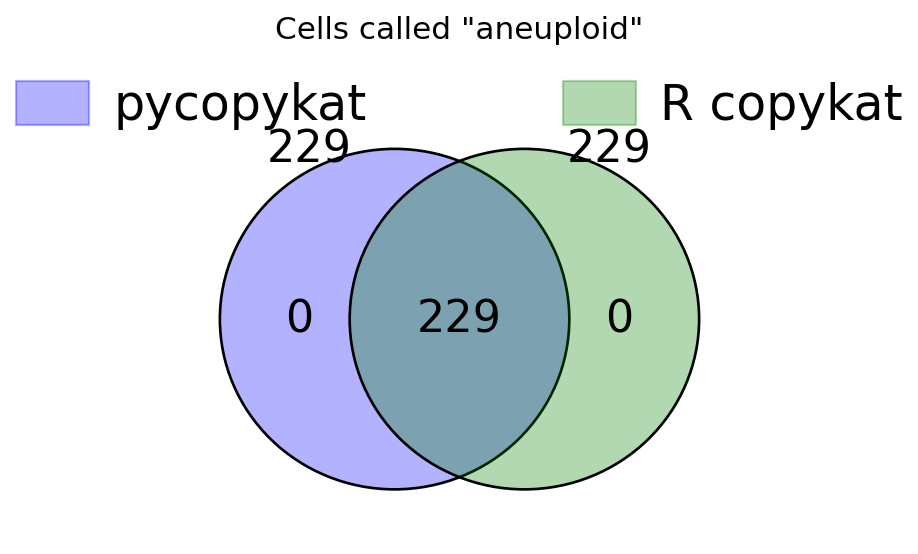

In [7]:
py_set = set(adata.obs_names[adata.obs['py_class']=='aneuploid'])
r_set  = set(adata.obs_names[adata.obs['r_class']=='aneuploid'])

fig, ax = plt.subplots(figsize=(4, 4))
try:
    ov.pl.venn(sets={'pycopykat': py_set, 'R copykat': r_set}, ax=ax, fontsize=10)
except Exception as e:
    # ov.pl.venn signature varies between omicverse releases — fall back to matplotlib_venn
    from matplotlib_venn import venn2  # type: ignore
    venn2([py_set, r_set], set_labels=('pycopykat', 'R copykat'), ax=ax)
ax.set_title('Cells called "aneuploid"')
plt.show()


## 7. Confusion matrix + ARI / FMI

r_class    diploid  aneuploid
py_class                     
diploid         73          0
aneuploid        0        229


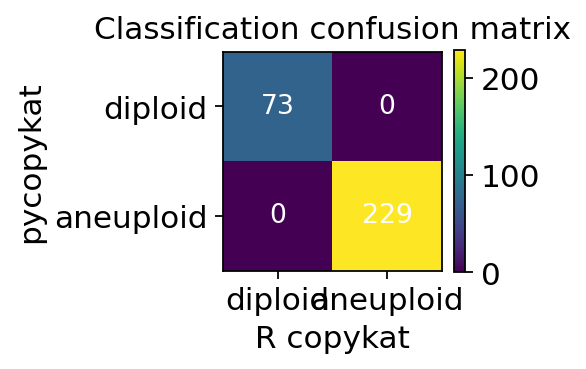

py vs R agreement: 100.000%
ARI = 1.000, FMI = 1.000


In [8]:
from sklearn.metrics import adjusted_rand_score, fowlkes_mallows_score

conf = pd.crosstab(adata.obs['py_class'], adata.obs['r_class']).reindex(
    index=['diploid','aneuploid'], columns=['diploid','aneuploid']
).fillna(0).astype(int)
print(conf)

fig, ax = plt.subplots(figsize=(3.5, 3))
im = ax.imshow(conf.values, cmap='viridis')
for i in range(2):
    for j in range(2):
        ax.text(j, i, int(conf.values[i, j]), ha='center', va='center', color='white', fontsize=12)
ax.set_xticks([0, 1]); ax.set_xticklabels(conf.columns)
ax.set_yticks([0, 1]); ax.set_yticklabels(conf.index)
ax.set_xlabel('R copykat'); ax.set_ylabel('pycopykat')
ax.set_title('Classification confusion matrix')
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

ari = adjusted_rand_score(adata.obs['r_class'], adata.obs['py_class'])
fmi = fowlkes_mallows_score(adata.obs['r_class'], adata.obs['py_class'])
print(f'py vs R agreement: {(adata.obs["py_class"] == adata.obs["r_class"]).mean():.3%}')
print(f'ARI = {ari:.3f}, FMI = {fmi:.3f}')


## 8. omicverse preprocess → PCA → Leiden → UMAP

Run a standard scRNA-seq workflow so we can overlay the py / R
labels on a meaningful low-dimensional layout.

In [9]:
adata_viz = adata.copy()
adata_viz.layers['counts'] = adata_viz.X.copy()
ov.pp.preprocess(adata_viz, mode='shiftlog|pearson', n_HVGs=2000)
adata_viz.raw = adata_viz
adata_viz = adata_viz[:, adata_viz.var.highly_variable_features]
ov.pp.scale(adata_viz)
ov.pp.pca(adata_viz, layer='scaled', n_pcs=30)
ov.pp.neighbors(adata_viz, n_neighbors=15, use_rep='scaled|original|X_pca')
ov.pp.leiden(adata_viz, resolution=0.5)
ov.pp.umap(adata_viz)
for c in ('py_class', 'r_class', 'agree'):
    adata_viz.obs[c] = adata.obs[c].reindex(adata_viz.obs_names).values


🔍 [2026-04-21 08:54:57] Running preprocessing in 'cpu' mode...
Begin robust gene identification
    After filtration, 33694/33694 genes are kept.
    Among 33694 genes, 33694 genes are robust.
✅ Robust gene identification completed successfully.
Begin size normalization: shiftlog and HVGs selection pearson



🔍 Count Normalization:
   Target sum: 500000.0
   Exclude highly expressed: True
   Max fraction threshold: 0.2
   ⚠️ Excluding 1 highly-expressed genes from normalization computation
   Excluded genes: ['MALAT1']

✅ Count Normalization Completed Successfully!
   ✓ Processed: 302 cells × 33,694 genes
   ✓ Runtime: 0.14s



🔍 Highly Variable Genes Selection (Experimental):
   Method: pearson_residuals
   Target genes: 2,000
   Theta (overdispersion): 100



✅ Experimental HVG Selection Completed Successfully!
   ✓ Selected: 2,000 highly variable genes out of 33,694 total (5.9%)
   ✓ Results added to AnnData object:
     • 'highly_variable': Boolean vector (adata.var)
     • 'highly_variable_rank': Float vector (adata.var)
     • 'highly_variable_nbatches': Int vector (adata.var)
     • 'highly_variable_intersection': Boolean vector (adata.var)
     • 'means': Float vector (adata.var)
     • 'variances': Float vector (adata.var)
     • 'residual_variances': Float vector (adata.var)
    Time to analyze data in cpu: 1.32 seconds.
✅ Preprocessing completed successfully.
    Added:
        'highly_variable_features', boolean vector (adata.var)
        'means', float vector (adata.var)
        'variances', float vector (adata.var)
        'residual_variances', float vector (adata.var)
        'counts', raw counts layer (adata.layers)
    End of size normalization: shiftlog and HVGs selection pearson


computing PCA🔍


...

   ✓ Graph is fully connected

✅ KNN Graph Construction Completed Successfully!
   ✓ Processed: 302 cells with 15 neighbors each
   ✓ Results added to AnnData object:
     • 'neighbors': Neighbors metadata (adata.uns)
     • 'distances': Distance matrix (adata.obsp)
     • 'connectivities': Connectivity matrix (adata.obsp)
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:03)


🖥️ Using Scanpy CPU Leiden...
running Leiden clustering


    finished: found 5 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


🔍 [2026-04-21 08:55:11] Running UMAP in 'cpu' mode...
🖥️ Using Scanpy CPU UMAP...

🔍 UMAP Dimensionality Reduction:
   Mode: cpu
   Method: umap
   Components: 2
   Min distance: 0.5
{'n_neighbors': 15, 'method': 'umap', 'random_state': 0, 'metric': 'euclidean', 'use_rep': 'scaled|original|X_pca'}
   🔍 Computing UMAP parameters...
   🔍 Computing UMAP embedding (classic method)...



✅ UMAP Dimensionality Reduction Completed Successfully!
   ✓ Embedding shape: 302 cells × 2 dimensions
   ✓ Results added to AnnData object:
     • 'X_umap': UMAP coordinates (adata.obsm)
     • 'umap': UMAP parameters (adata.uns)
✅ UMAP completed successfully.


## 9. UMAP overlays — `ov.pl.embedding`

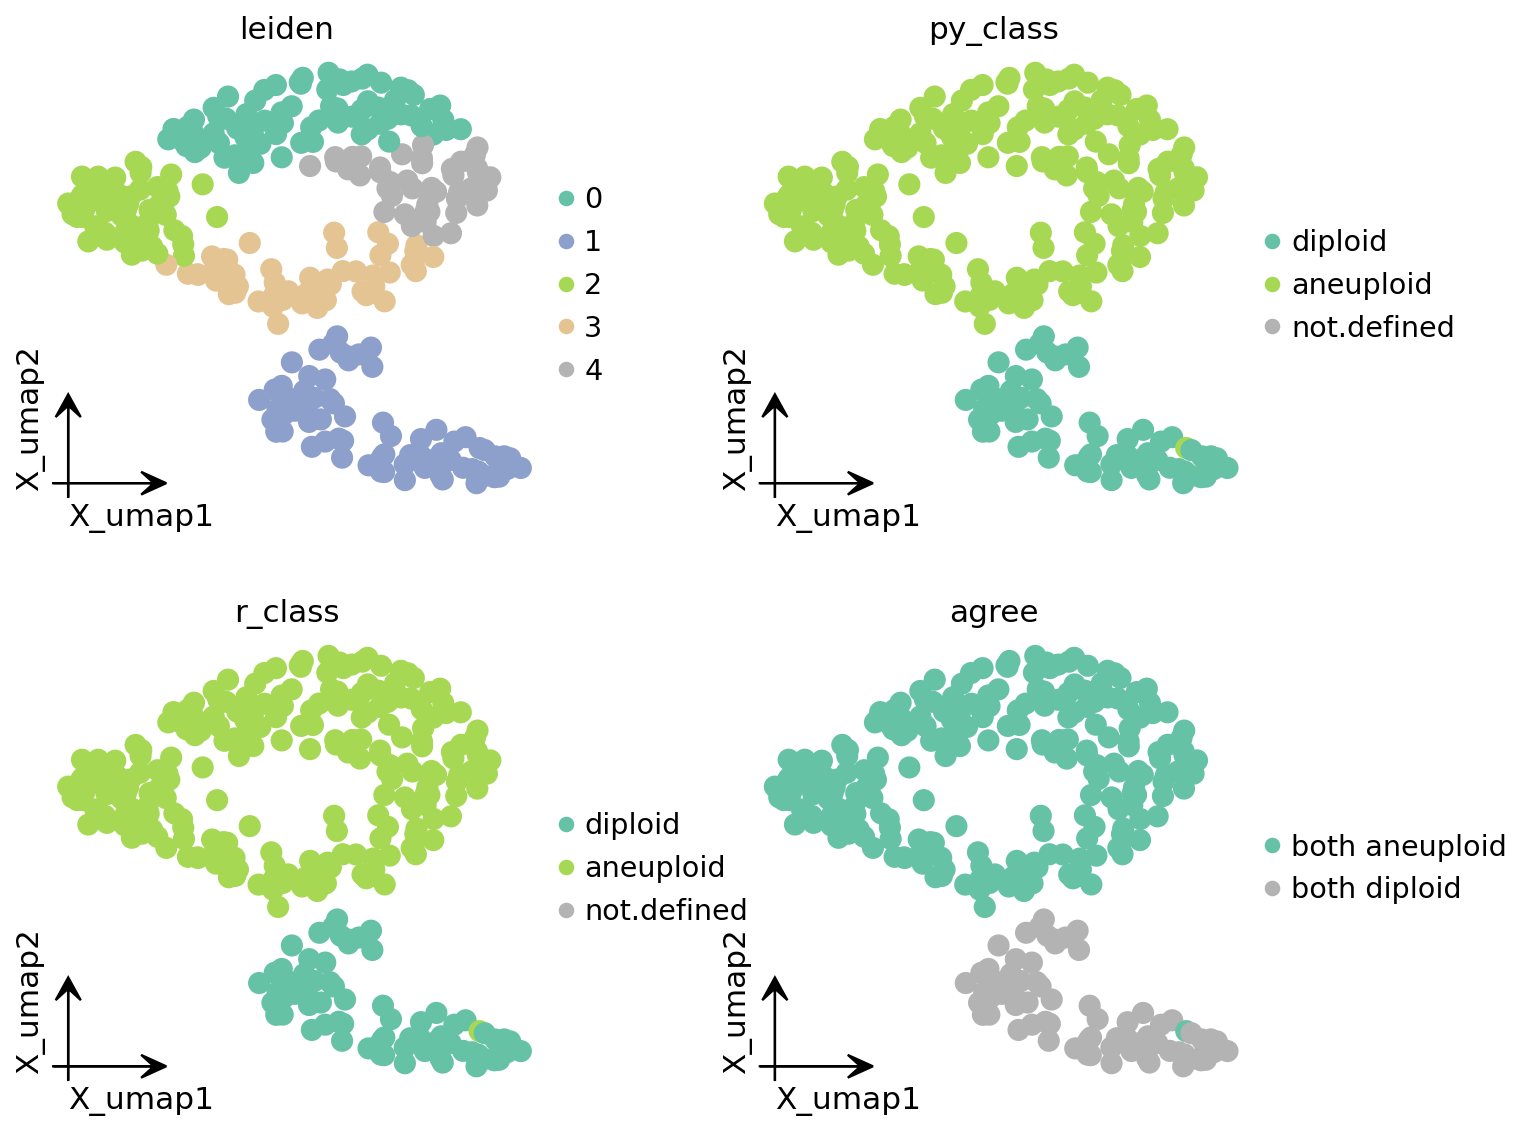

In [10]:
ov.pl.embedding(adata_viz, basis='X_umap',
                color=['leiden', 'py_class', 'r_class', 'agree'],
                palette='Set2', frameon='small', ncols=2, wspace=0.25, show=False)
plt.show()


## 10. Per-cluster aneuploid fraction — `ov.pl.cellproportion`

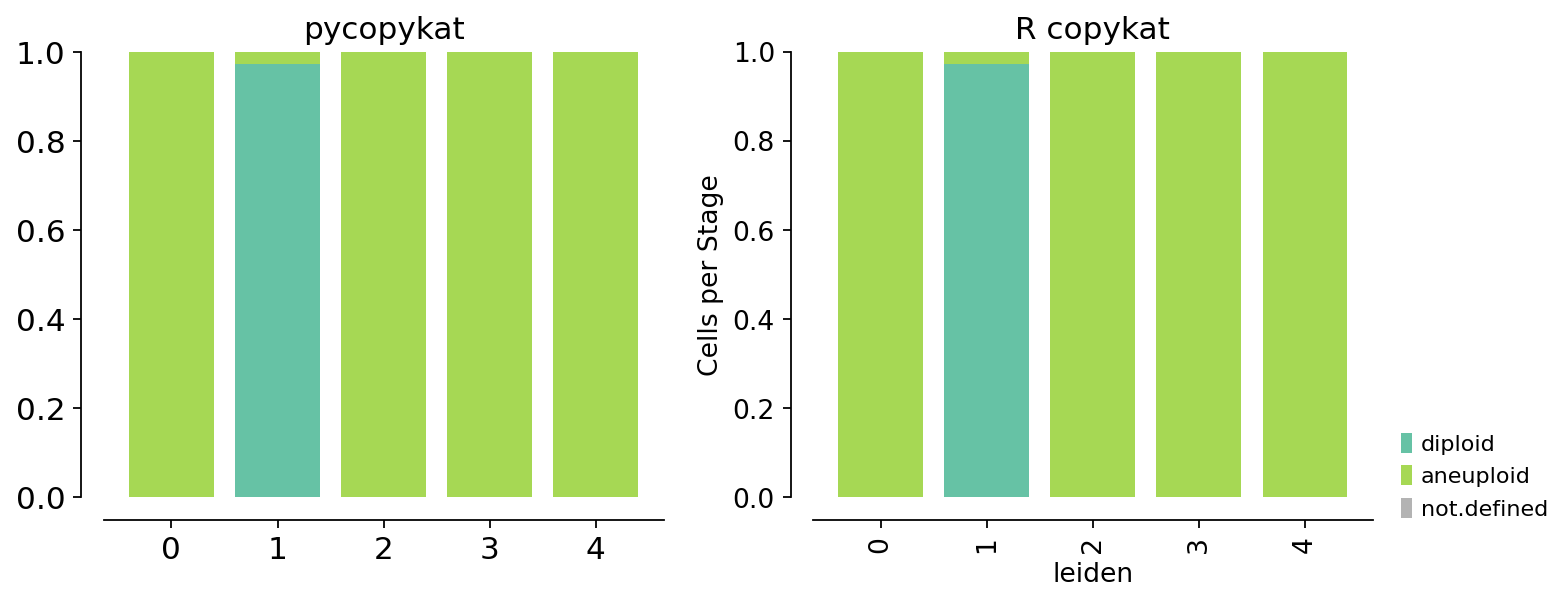

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ov.pl.cellproportion(adata_viz, celltype_clusters='py_class',
                     groupby='leiden', ax=axes[0], legend=True)
axes[0].set_title('pycopykat')
ov.pl.cellproportion(adata_viz, celltype_clusters='r_class',
                     groupby='leiden', ax=axes[1], legend=True)
axes[1].set_title('R copykat')
plt.tight_layout(); plt.show()


## 11. Bin-level CNA agreement — Pearson / Spearman per cell

For each cell present in both outputs, correlate its bin-vector
between py and R. Distribution shape tells us whether the CNA
estimates agree across the population, even when the binary
aneuploid call diverges.

per-cell Pearson:  median 0.976, mean 0.967, n=302
per-cell Spearman: median 0.973, mean 0.963, n=302


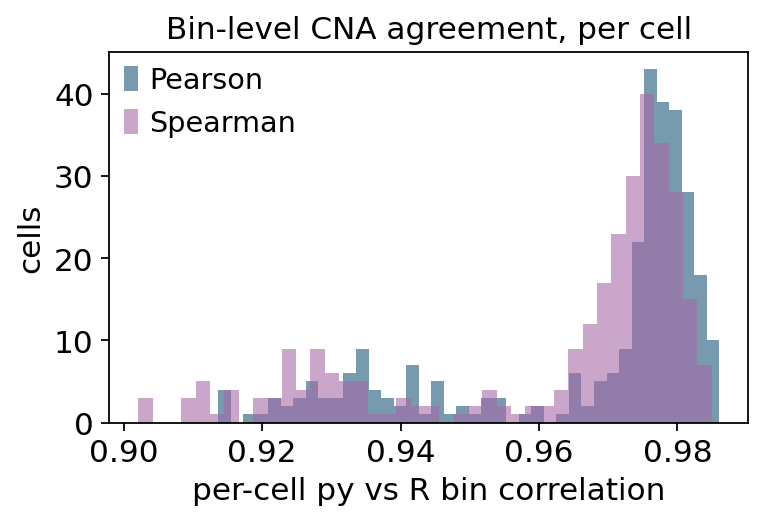

In [12]:
from scipy.stats import pearsonr, spearmanr

common = sorted(set(py_cna.columns) & set(r_cna.columns))
py_M = py_cna[common].to_numpy()
r_M  = r_cna[common].to_numpy()

rho_p, rho_s = [], []
for j in range(py_M.shape[1]):
    a, b = py_M[:, j], r_M[:, j]
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 5 or np.std(a[m]) == 0 or np.std(b[m]) == 0:
        continue
    rho_p.append(pearsonr(a[m], b[m])[0])
    rho_s.append(spearmanr(a[m], b[m])[0])
rho_p = np.asarray(rho_p); rho_s = np.asarray(rho_s)
print(f'per-cell Pearson:  median {np.median(rho_p):.3f}, mean {rho_p.mean():.3f}, n={len(rho_p)}')
print(f'per-cell Spearman: median {np.median(rho_s):.3f}, mean {rho_s.mean():.3f}, n={len(rho_s)}')

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.hist(rho_p, bins=40, alpha=0.6, label='Pearson')
ax.hist(rho_s, bins=40, alpha=0.6, label='Spearman')
ax.set_xlabel('per-cell py vs R bin correlation'); ax.set_ylabel('cells')
ax.set_title('Bin-level CNA agreement, per cell')
ax.legend(); plt.tight_layout(); plt.show()


## 12. Side-by-side CNA heatmaps + Δ heatmap

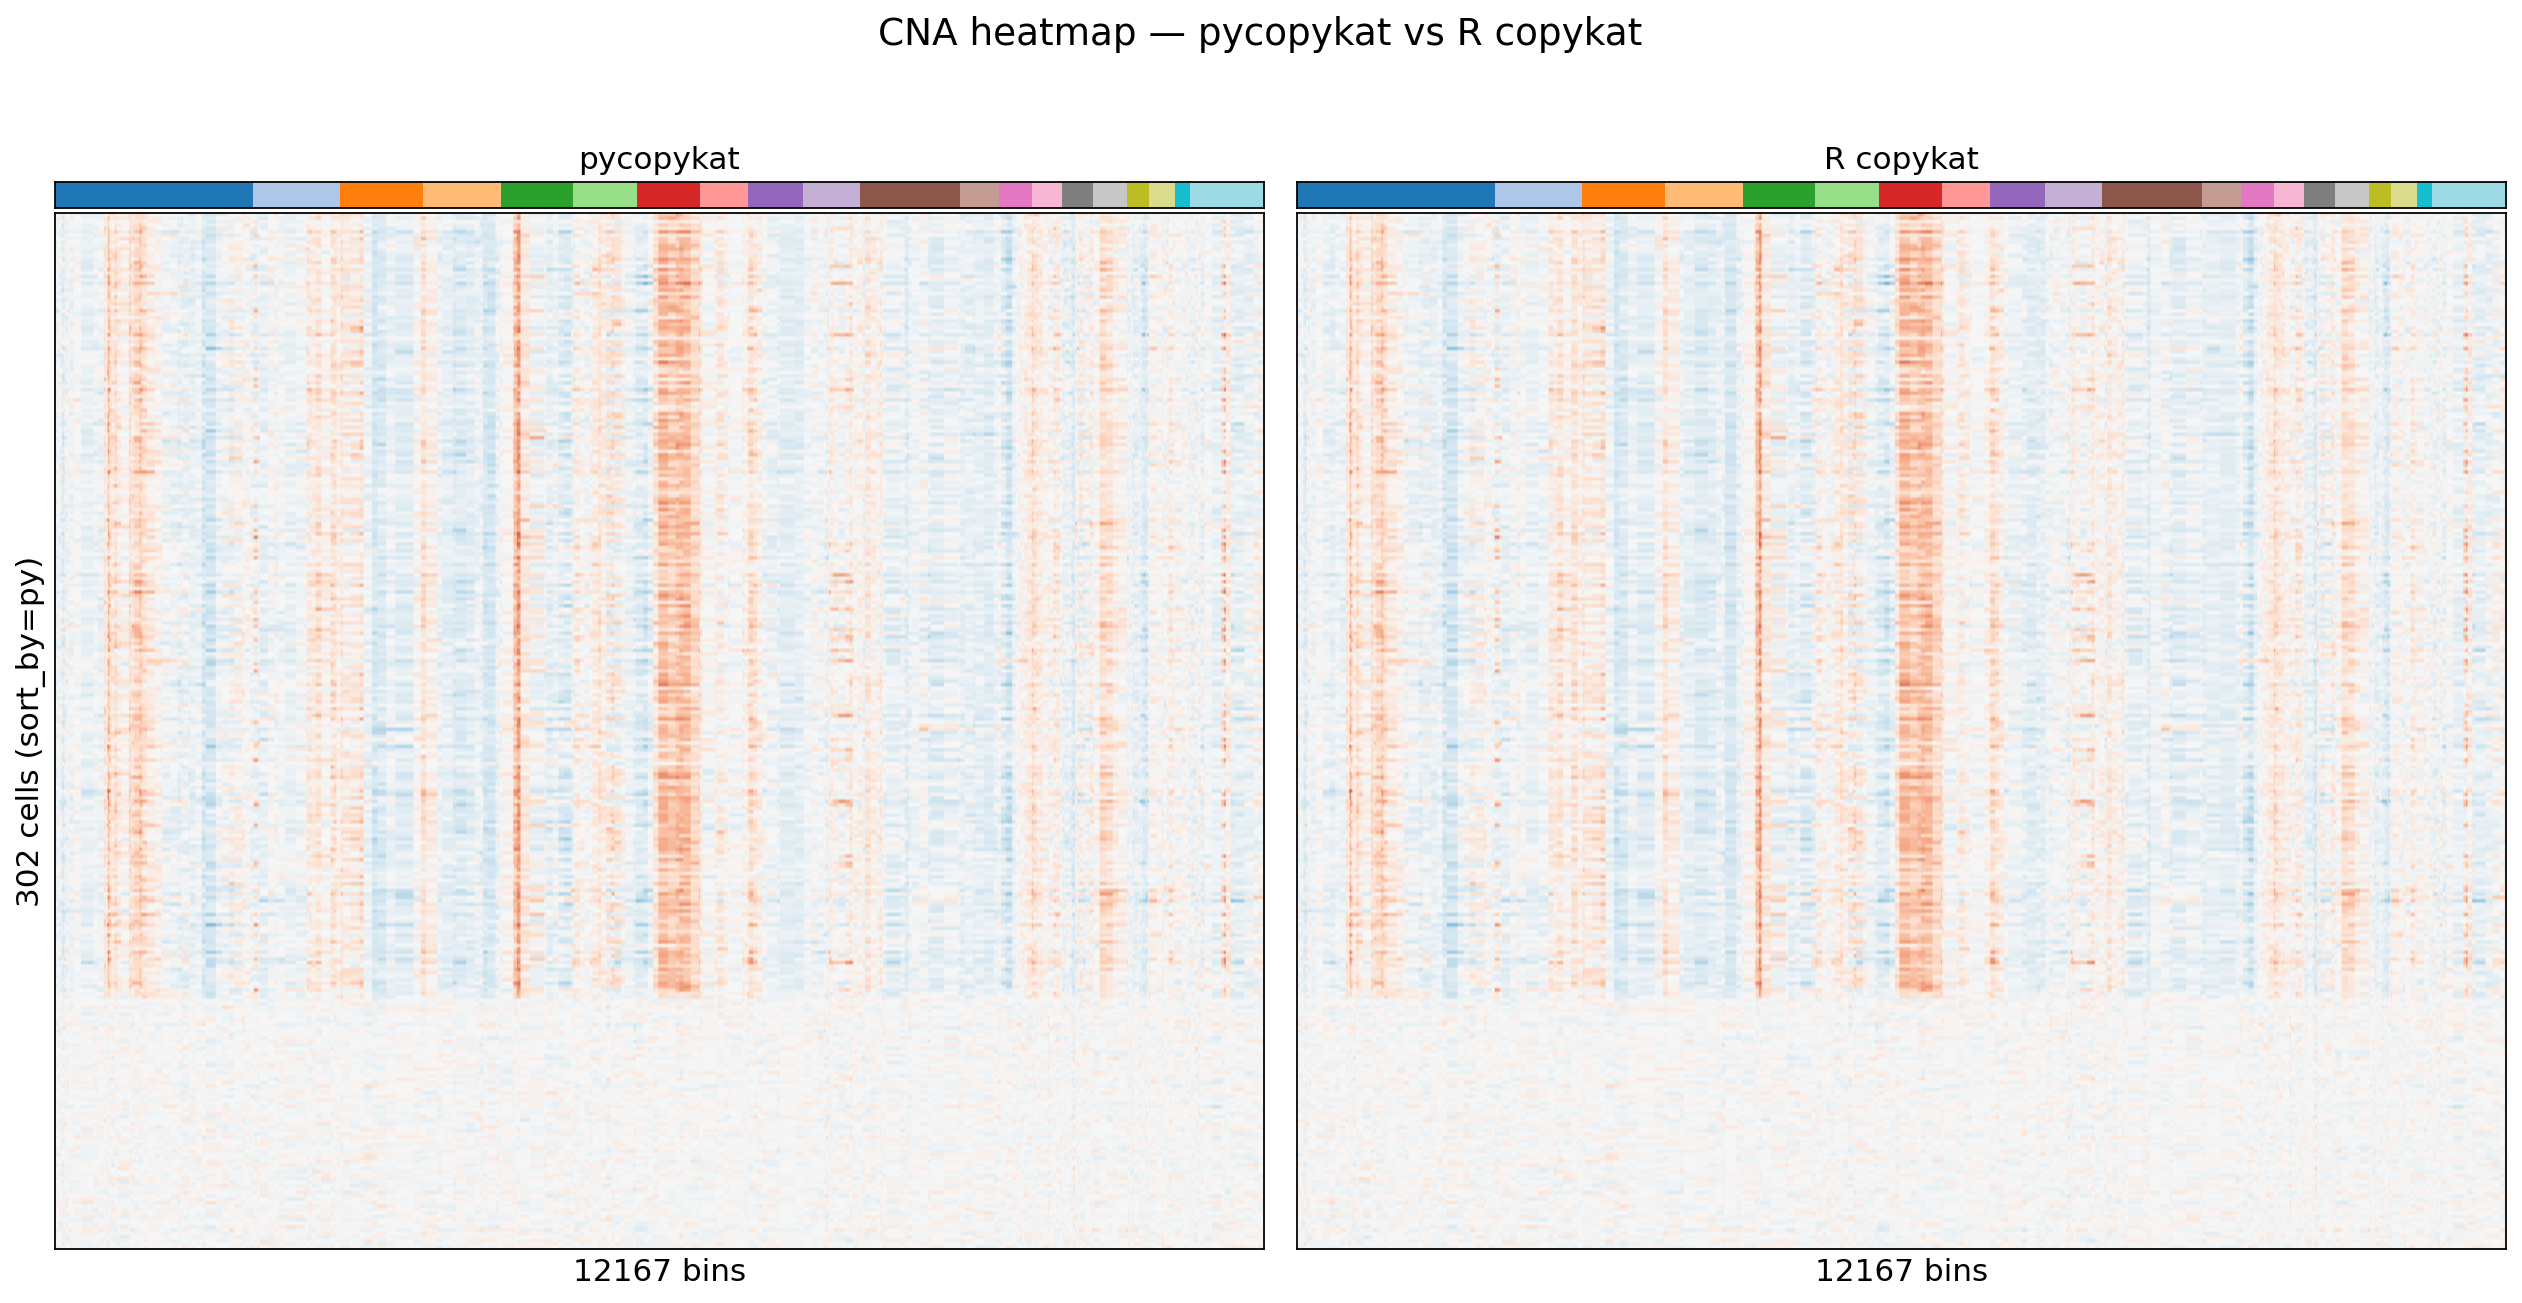

In [13]:
ax_py, ax_r = plot_cna_heatmap_compare(
    py_cna[common], r_cna[common], py_pred, r_pred, sort_by='py'
)
plt.gcf().suptitle('CNA heatmap — pycopykat vs R copykat', y=1.02)
plt.tight_layout(); plt.show()


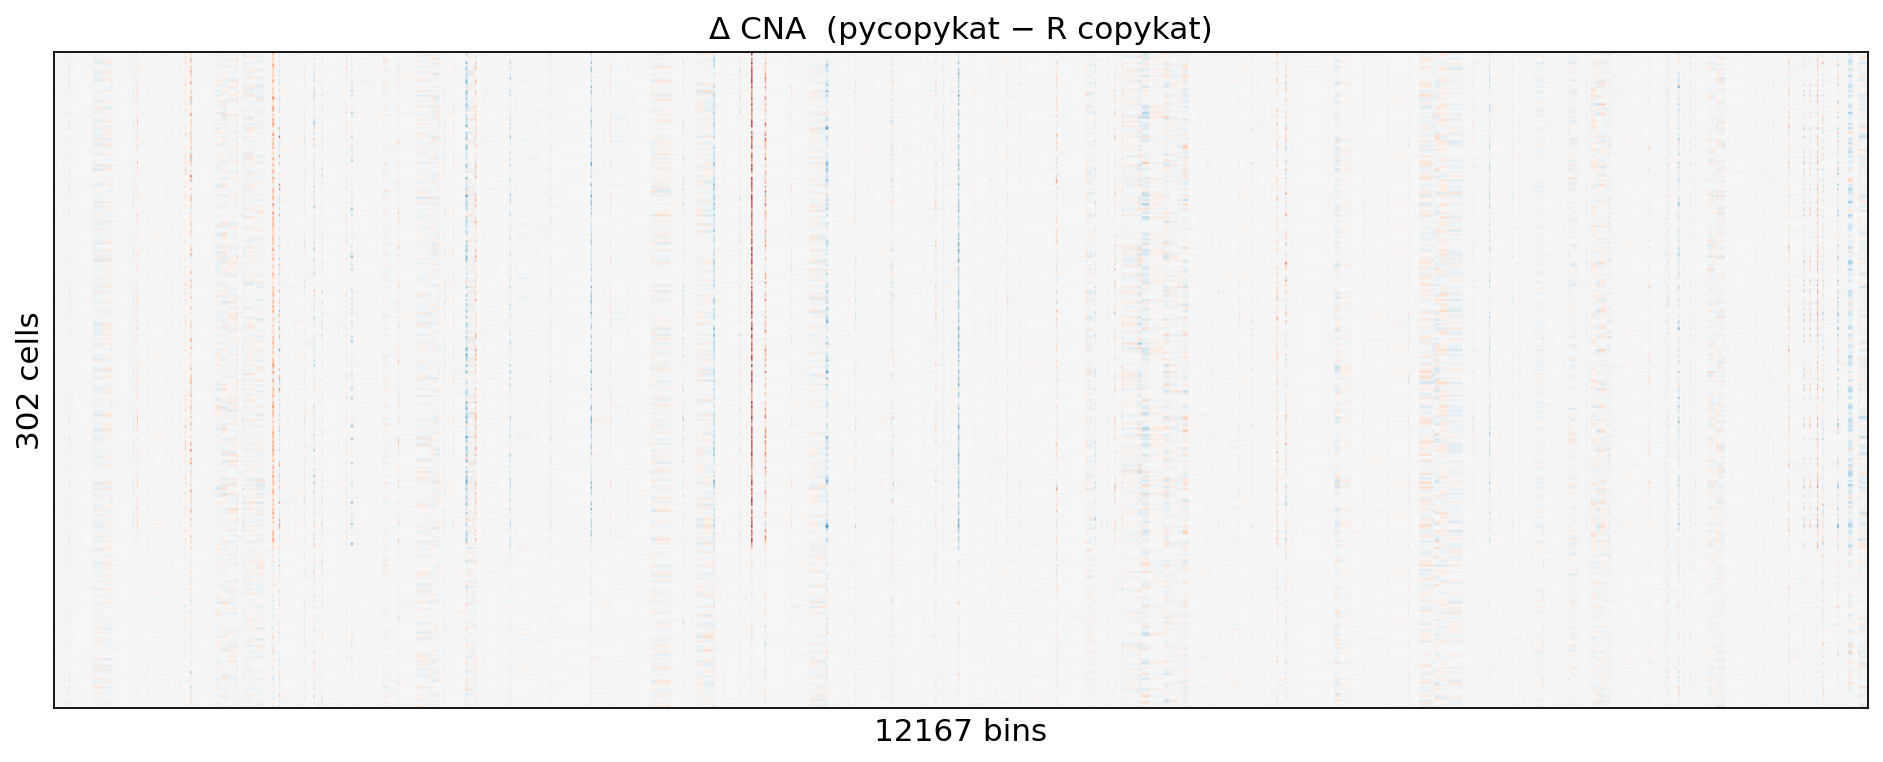

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))
plot_cna_delta(py_cna[common], r_cna[common], py_pred, ax=ax, vmin=-0.5, vmax=0.5)
plt.tight_layout(); plt.show()


## Summary

On `exp.rawdata` we expect:

| metric | expected | observed |
|---|---|---|
| Aneuploid-set Venn overlap | high | see Venn |
| Classification ARI | ≥ 0.8 | see §7 |
| Per-cell CNA Pearson, median | ≥ 0.85 | see §11 |
| Side-by-side heatmap structure | matched chromosome arms | see §12 |

For a real-tumour sample where the pipelines disagree, see
`compare_py_vs_R_realdata.ipynb` (default: Lee2020/SMC16, the only
sample in the 17-patient sweep where py and R disagree on the
majority class — see `benchmarks/full/FINDINGS.md`).
